# Thesis Results Notebook

This notebook is the dissertation-facing entry point for aggregating and comparing evaluation results.

In [1]:
from pathlib import Path
import sys

SEARCH_ROOT = Path.cwd().resolve()
if (SEARCH_ROOT / "evaluation" / "load_results.py").exists():
    sys.path.insert(0, str(SEARCH_ROOT))
elif (SEARCH_ROOT / "load_results.py").exists():
    sys.path.insert(0, str(SEARCH_ROOT.parent))
else:
    raise RuntimeError("Could not locate the evaluation helpers from the current working directory")

import matplotlib.pyplot as plt
import pandas as pd

from evaluation.load_results import load_results
from evaluation.coverage import compute_coverage, missing_oracle_gap_summary
from evaluation.aggregate import summarize_results, family_summary, oracle_comparison_summary, ai_ablation_summary
from evaluation.plots import plot_metric_bars, plot_metric_by_dynamicity, plot_tradeoff_scatter, plot_family_heatmaps


In [2]:
df = load_results()
coverage = compute_coverage(df)
overall = summarize_results(df, ["modality_group", "model_display_name", "evaluation_size"])
oracle_summary = oracle_comparison_summary(df)
family = family_summary(df)
ablation = ai_ablation_summary(df)

print(f"Loaded {len(df):,} result rows")
coverage

Loaded 18,167 result rows


,modality_group,model_name,evaluation_size,observed_runs,expected_runs,missing_runs,coverage_ratio,instance_count,seed_count,dod_count,cutoff_count,oracle_gap_coverage_ratio,feasible_rate
0,ai,general_50,50,1505,1512,7,0.995370,56,3,3,3,1.0,0.091694
1,ai,general_50,75,1512,1512,0,1.000000,56,3,3,3,0.0,0.031746
2,ai,routefinder_solomon_generated_50,50,1505,1512,7,0.995370,56,3,3,3,1.0,0.097010
3,ai,routefinder_solomon_generated_50,75,1512,1512,0,1.000000,56,3,3,3,0.0,0.038360
4,ai,routefinder_solomon_generated_75,50,1505,1512,7,0.995370,56,3,3,3,1.0,0.134884
5,ai,routefinder_solomon_generated_75,75,1512,1512,0,1.000000,56,3,3,3,0.0,0.050926
6,ai,routefinder_with_lateness_50,50,1506,1512,6,0.996032,56,3,3,3,1.0,0.110226
7,ai,routefinder_with_lateness_50,75,1512,1512,0,1.000000,56,3,3,3,0.0,0.025132
8,ai,routefinder_with_lateness_75,50,1506,1512,6,0.996032,56,3,3,3,1.0,0.100266
9,ai,routefinder_with_lateness_75,75,1512,1512,0,1.000000,56,3,3,3,0.0,0.021164


## Coverage Check

Always inspect benchmark completeness before drawing conclusions.

In [3]:
missing_oracle_gap_summary(df)

,model_name,evaluation_size,runs,missing_oracle_gap,available_oracle_gap,availability_ratio
0,general_50,50,1505,0,1505,1.0
1,general_50,75,1512,1512,0,0.0
2,ortools,50,1512,1512,0,0.0
3,ortools,75,1512,1512,0,0.0
4,routefinder_solomon_generated_50,50,1505,0,1505,1.0
5,routefinder_solomon_generated_50,75,1512,1512,0,0.0
6,routefinder_solomon_generated_75,50,1505,0,1505,1.0
7,routefinder_solomon_generated_75,75,1512,1512,0,0.0
8,routefinder_with_lateness_50,50,1506,0,1506,1.0
9,routefinder_with_lateness_50,75,1512,1512,0,0.0


## Overall Performance

In [4]:
overall

,modality_group,model_display_name,evaluation_size,runs,feasible_rate,total_distance_mean,total_distance_median,num_vehicles_mean,num_vehicles_median,average_lateness_mean,...,rejection_rate_mean,rejection_rate_median,service_level_mean,service_level_median,computational_time_mean,computational_time_median,total_cost_mean,total_cost_median,oracle_gap_mean,oracle_gap_median
0,ai,RouteFinder General 50,50,1505,0.091694,1854.836545,1836.0,7.603987,7.0,26.232626,...,0.000080,0.0,0.648568,0.760000,0.00000,0.000000,2615.235216,2621.0,170.255620,124.528302
1,ai,RouteFinder General 50,75,1512,0.031746,3073.698413,2929.0,11.441799,11.0,38.600960,...,0.000220,0.0,0.590722,0.653333,0.00000,0.000000,4217.878307,4061.5,NaN,NaN
2,ai,RouteFinder Late 50,50,1506,0.110226,1769.245684,1757.0,7.219124,6.0,24.555984,...,0.000120,0.0,0.663855,0.780000,0.00000,0.000000,2491.158035,2504.5,149.336775,131.976011
3,ai,RouteFinder Late 50,75,1512,0.025132,2847.612434,2821.0,10.433862,9.0,39.589858,...,0.000141,0.0,0.582635,0.640000,0.00000,0.000000,3890.998677,3918.5,NaN,NaN
4,ai,RouteFinder Late 75,50,1506,0.100266,1806.073705,1807.0,7.735724,6.0,24.927579,...,0.000080,0.0,0.665061,0.760000,0.00000,0.000000,2579.646082,2558.5,149.757442,130.413143
5,ai,RouteFinder Late 75,75,1512,0.021164,2848.220238,2779.5,11.154101,8.0,38.975281,...,0.000767,0.0,0.587062,0.640000,0.00000,0.000000,3963.630291,3870.0,NaN,NaN
6,ai,RouteFinder Solomon 50,50,1505,0.097010,2083.957475,1978.0,8.962791,8.0,18.489515,...,0.000106,0.0,0.725835,0.820000,0.00000,0.000000,2980.236545,2843.0,192.303561,175.795190
7,ai,RouteFinder Solomon 50,75,1512,0.038360,3459.781085,3331.5,13.193122,12.0,25.685316,...,0.007769,0.0,0.689267,0.773333,0.00000,0.000000,4779.093254,4686.5,NaN,NaN
8,ai,RouteFinder Solomon 75,50,1505,0.134884,2590.649834,2376.0,10.328904,10.0,14.702664,...,0.000013,0.0,0.740867,0.860000,0.00000,0.000000,3623.540199,3461.0,282.681493,234.727273
9,ai,RouteFinder Solomon 75,75,1512,0.050926,3736.632937,3504.0,13.203042,13.0,21.292577,...,0.000018,0.0,0.698749,0.813333,0.00000,0.000000,5056.937169,4903.5,NaN,NaN


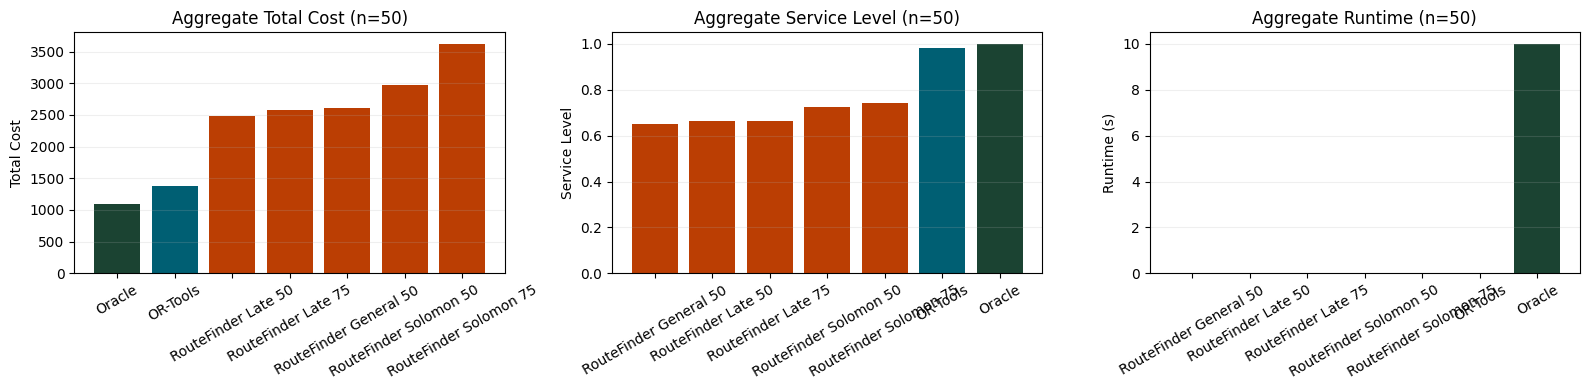

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_metric_bars(overall[overall["evaluation_size"].eq(50)], metric="total_cost", ax=axes[0])
axes[0].set_title("Aggregate Total Cost (n=50)")
plot_metric_bars(overall[overall["evaluation_size"].eq(50)], metric="service_level", ax=axes[1])
axes[1].set_title("Aggregate Service Level (n=50)")
plot_metric_bars(overall[overall["evaluation_size"].eq(50)], metric="computational_time", ax=axes[2])
axes[2].set_title("Aggregate Runtime (n=50)")
fig.tight_layout()


## Dynamicity Effects

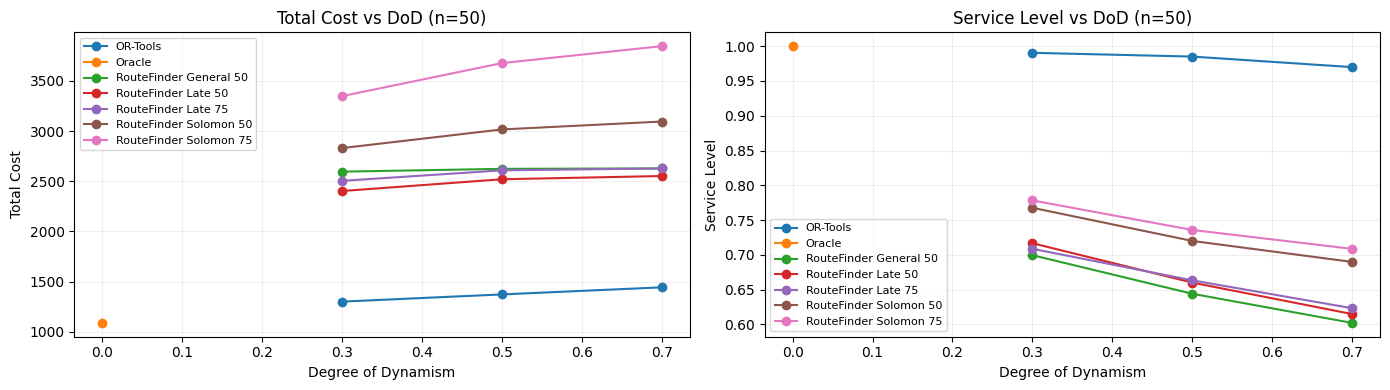

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_metric_by_dynamicity(df[df["evaluation_size"].eq(50)], metric="total_cost", ax=axes[0])
axes[0].set_title("Total Cost vs DoD (n=50)")
plot_metric_by_dynamicity(df[df["evaluation_size"].eq(50)], metric="service_level", ax=axes[1])
axes[1].set_title("Service Level vs DoD (n=50)")
fig.tight_layout()


## Solomon Family Comparison

In [7]:
family

,model_display_name,instance_family,evaluation_size,runs,feasible_rate,total_distance_mean,total_distance_median,num_vehicles_mean,num_vehicles_median,average_lateness_mean,...,rejection_rate_mean,rejection_rate_median,service_level_mean,service_level_median,computational_time_mean,computational_time_median,total_cost_mean,total_cost_median,oracle_gap_mean,oracle_gap_median
0,OR-Tools,C,50,459,0.708061,445.888889,443.0,5.119826,5.0,0.079564,...,0.000000,0.0,0.993377,1.000000,0.000000,0.000000,957.871460,887.0,NaN,NaN
1,OR-Tools,C,75,459,0.535948,705.215686,697.0,7.520697,8.0,0.086420,...,0.000000,0.0,0.991692,1.000000,0.000000,0.000000,1457.285403,1473.0,NaN,NaN
2,OR-Tools,R,50,621,0.566828,835.112721,816.0,8.101449,8.0,0.159393,...,0.001836,0.0,0.977317,1.000000,0.000000,0.000000,1645.257649,1570.0,NaN,NaN
3,OR-Tools,R,75,621,0.505636,1119.413849,1071.0,11.162641,10.0,0.161569,...,0.001181,0.0,0.975618,1.000000,0.000000,0.000000,2235.677939,2112.0,NaN,NaN
4,OR-Tools,RC,50,432,0.638889,774.245370,736.5,6.432870,5.0,0.168598,...,0.003796,0.0,0.975926,1.000000,0.000000,0.000000,1417.532407,1266.5,NaN,NaN
5,OR-Tools,RC,75,432,0.479167,1220.006944,1172.0,10.395833,10.0,0.154284,...,0.002870,0.0,0.977071,0.986667,0.000000,0.000000,2259.590278,2138.5,NaN,NaN
6,Oracle,C,50,17,1.000000,347.764706,347.0,3.941176,5.0,0.000000,...,0.000000,0.0,1.000000,1.000000,10.001833,10.001185,741.882353,847.0,NaN,NaN
7,Oracle,R,50,23,1.000000,683.608696,681.0,5.956522,6.0,0.000000,...,0.000000,0.0,1.000000,1.000000,10.001503,10.001278,1279.260870,1227.0,NaN,NaN
8,Oracle,RC,50,16,1.000000,638.062500,612.0,5.437500,5.0,0.000000,...,0.000000,0.0,1.000000,1.000000,10.001983,10.001767,1181.812500,1147.0,NaN,NaN
9,RouteFinder General 50,C,50,452,0.141593,1705.272124,1687.0,7.137168,6.0,28.560141,...,0.000044,0.0,0.757629,0.880000,0.000000,0.000000,2418.988938,2372.0,250.329752,223.512433


(<Figure size 1200x400 with 6 Axes>,
 array([[<Axes: title={'center': 'C'}>, <Axes: title={'center': 'R'}>,
         <Axes: title={'center': 'RC'}>]], dtype=object))

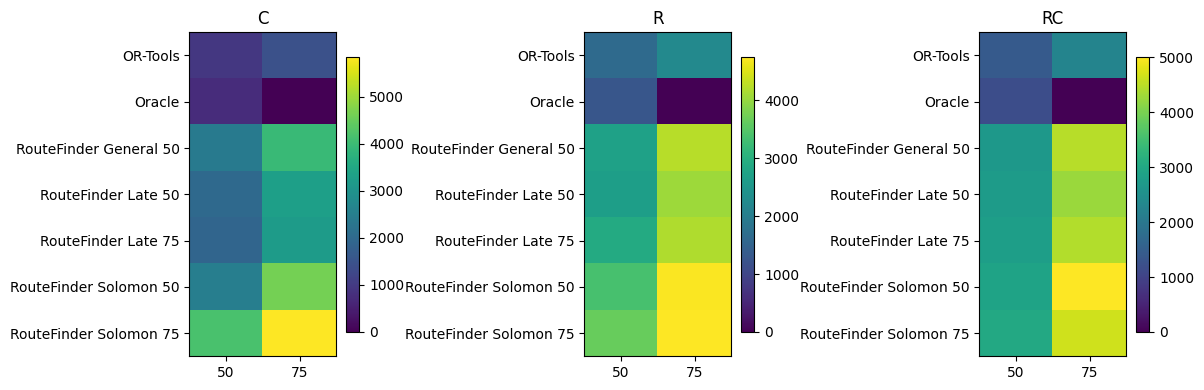

In [8]:
plot_family_heatmaps(family, metric="total_cost")


## Oracle Comparison

This section is intentionally restricted to subsets where `oracle_gap` is available.

In [9]:
oracle_summary

,model_display_name,evaluation_size,runs,feasible_rate,oracle_gap_mean,oracle_gap_median,total_cost_mean,total_cost_median,total_distance_mean,total_distance_median,service_level_mean,service_level_median
0,RouteFinder General 50,50,1505,0.091694,170.255620,124.528302,2615.235216,2621.0,1854.836545,1836.0,0.648568,0.76
1,RouteFinder Late 50,50,1506,0.110226,149.336775,131.976011,2491.158035,2504.5,1769.245684,1757.0,0.663855,0.78
2,RouteFinder Late 75,50,1506,0.100266,149.757442,130.413143,2579.646082,2558.5,1806.073705,1807.0,0.665061,0.76
3,RouteFinder Solomon 50,50,1505,0.097010,192.303561,175.795190,2980.236545,2843.0,2083.957475,1978.0,0.725835,0.82
4,RouteFinder Solomon 75,50,1505,0.134884,282.681493,234.727273,3623.540199,3461.0,2590.649834,2376.0,0.740867,0.86


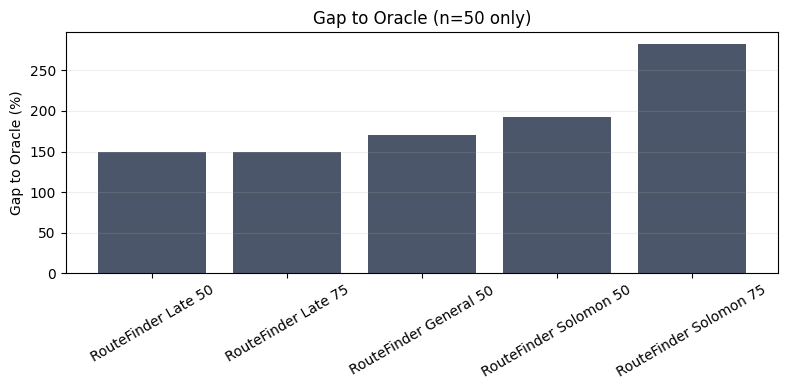

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric_bars(oracle_summary[oracle_summary["evaluation_size"].eq(50)], metric="oracle_gap", ax=ax)
ax.set_title("Gap to Oracle (n=50 only)")
fig.tight_layout()


## AI Ablation

In [11]:
ablation

,model_display_name,model_variant,evaluation_size,runs,feasible_rate,total_cost_mean,total_cost_median,total_distance_mean,total_distance_median,average_lateness_mean,average_lateness_median,service_level_mean,service_level_median,oracle_gap_mean,oracle_gap_median
0,RouteFinder General 50,general,50,1505,0.091694,2615.235216,2621.0,1854.836545,1836.0,26.232626,9.840000,0.648568,0.760000,170.255620,124.528302
1,RouteFinder General 50,general,75,1512,0.031746,4217.878307,4061.5,3073.698413,2929.0,38.600960,21.926667,0.590722,0.653333,NaN,NaN
2,RouteFinder Late 50,with_lateness,50,1506,0.110226,2491.158035,2504.5,1769.245684,1757.0,24.555984,9.030000,0.663855,0.780000,149.336775,131.976011
3,RouteFinder Late 50,with_lateness,75,1512,0.025132,3890.998677,3918.5,2847.612434,2821.0,39.589858,25.466667,0.582635,0.640000,NaN,NaN
4,RouteFinder Late 75,with_lateness,50,1506,0.100266,2579.646082,2558.5,1806.073705,1807.0,24.927579,9.330000,0.665061,0.760000,149.757442,130.413143
5,RouteFinder Late 75,with_lateness,75,1512,0.021164,3963.630291,3870.0,2848.220238,2779.5,38.975281,26.606667,0.587062,0.640000,NaN,NaN
6,RouteFinder Solomon 50,solomon_generated,50,1505,0.097010,2980.236545,2843.0,2083.957475,1978.0,18.489515,6.880000,0.725835,0.820000,192.303561,175.795190
7,RouteFinder Solomon 50,solomon_generated,75,1512,0.038360,4779.093254,4686.5,3459.781085,3331.5,25.685316,16.693333,0.689267,0.773333,NaN,NaN
8,RouteFinder Solomon 75,solomon_generated,50,1505,0.134884,3623.540199,3461.0,2590.649834,2376.0,14.702664,4.860000,0.740867,0.860000,282.681493,234.727273
9,RouteFinder Solomon 75,solomon_generated,75,1512,0.050926,5056.937169,4903.5,3736.632937,3504.0,21.292577,10.626667,0.698749,0.813333,NaN,NaN


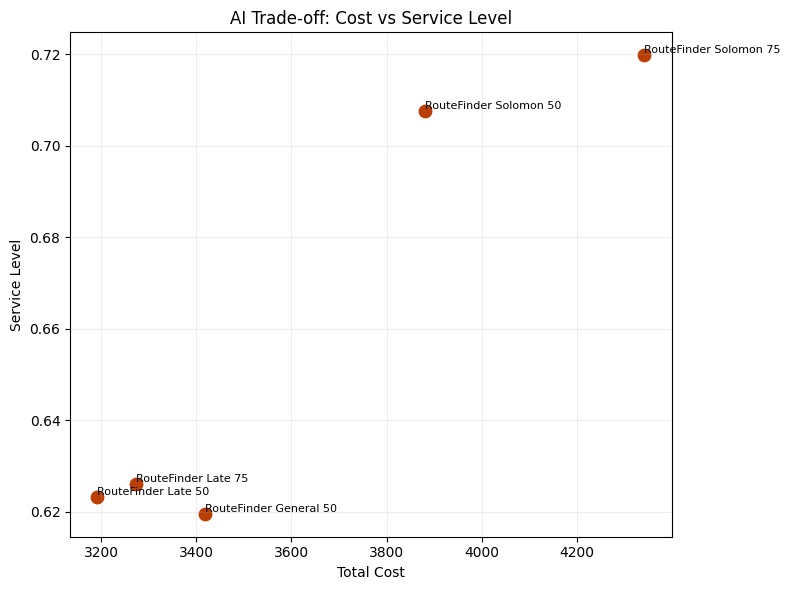

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_tradeoff_scatter(df[df["modality_group"].eq("ai")], x="total_cost", y="service_level", ax=ax)
ax.set_title("AI Trade-off: Cost vs Service Level")
fig.tight_layout()
